# Predicting Melanoma-Related Death: A Binary Classification Approach

**Data Science for Psychology and Neuroscience — Final Project**  
**Dataset:** `melanoma` (from built-in, `boot` package, R)  
Name: Tina Wang

---

## Overview

Melanoma is the most aggressive form of skin cancer, and understanding which patient and tumor characteristics predict mortality is of direct clinical relevance. This project uses the `melanoma` dataset (a prospective cohort of 205 patients who underwent surgical removal of malignant melanoma at Odense University Hospital in Denmark between 1962 and 1977) to address the following research question:

> **What patient and tumor characteristics predict melanoma-related death, and how well can a binary logistic regression model classify survival outcomes?**

The dataset contains the following variables:

| Variable | Description |
|---|---|
| `time` | Survival time (days) from surgery to death, last follow-up, or censoring |
| `status` | Outcome: **1** = died from melanoma, **2** = alive at end of study, **3** = died from other causes |
| `sex` | 1 = male, 0 = female |
| `age` | Age at time of surgery (years) |
| `year` | Year of surgery |
| `thickness` | Tumor thickness (mm) |
| `ulcer` | Ulceration status: 1 = present, 0 = absent |

### Analytical Plan

This project proceeds in four stages:

1. **Descriptive statistics**: aiming to understand the structure, distributions, and class balance of the data
2. **Correlation / multicollinearity analysis**: aiming to examine pairwise relationships among predictors before modeling
3. **Binary logistic regression**: aiming to model melanoma-related death vs. all other outcomes, evaluating coefficients and model fit
4. **Model evaluation**: aiming to use k-fold cross-validation and bootstrapping to assess the reliability of our classifier

Throughout this project, analytical decisions are directly motivated by the research question posed.

---
## Section 1: Setup and Data Loading


In [1]:
# Load required libraries
library(boot)      # contains the melanoma dataset
library(ggplot2)   # for visualization

data(melanoma)

# Preview the data
head(melanoma)

,time,status,sex,age,year,thickness,ulcer
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,10,3,1,76,1972,6.76,1
2,30,3,1,56,1968,0.65,0
3,35,2,1,41,1977,1.34,0
4,99,3,0,71,1968,2.90,0
5,185,1,1,52,1965,12.08,1
6,204,1,1,28,1971,4.84,1


In [2]:
# Check dimensions and structure
dim(melanoma)
str(melanoma)

[1] 205   7

'data.frame':	205 obs. of  7 variables:
 $ time     : num  10 30 35 99 185 204 210 232 232 279 ...
 $ status   : num  3 3 2 3 1 1 1 3 1 1 ...
 $ sex      : num  1 1 1 0 1 1 1 0 1 0 ...
 $ age      : num  76 56 41 71 52 28 77 60 49 68 ...
 $ year     : num  1972 1968 1977 1968 1965 ...
 $ thickness: num  6.76 0.65 1.34 2.9 12.08 ...
 $ ulcer    : num  1 0 0 0 1 1 1 1 1 1 ...


In [3]:
# Check for missing values
sum(is.na(melanoma))

[1] 0

There are no missing values in this dataset, so no removals are needed.


---
## Section 2: Descriptive Statistics

Before any modeling, it is essential to understand the shape and distribution of our variables. This is especially important for the outcome variable (`status`), since class imbalance can substantially affect how classifier performance is interpreted.


In [4]:
# Full summary of all variables
summary(melanoma)

      time          status          sex              age             year     
 Min.   :  10   Min.   :1.00   Min.   :0.0000   Min.   : 4.00   Min.   :1962  
 1st Qu.:1525   1st Qu.:1.00   1st Qu.:0.0000   1st Qu.:42.00   1st Qu.:1968  
 Median :2005   Median :2.00   Median :0.0000   Median :54.00   Median :1970  
 Mean   :2153   Mean   :1.79   Mean   :0.3854   Mean   :52.46   Mean   :1970  
 3rd Qu.:3042   3rd Qu.:2.00   3rd Qu.:1.0000   3rd Qu.:65.00   3rd Qu.:1972  
 Max.   :5565   Max.   :3.00   Max.   :1.0000   Max.   :95.00   Max.   :1977  
   thickness         ulcer      
 Min.   : 0.10   Min.   :0.000  
 1st Qu.: 0.97   1st Qu.:0.000  
 Median : 1.94   Median :0.000  
 Mean   : 2.92   Mean   :0.439  
 3rd Qu.: 3.56   3rd Qu.:1.000  
 Max.   :17.42   Max.   :1.000  

### 2.1 Distribution of the Outcome Variable

The `status` variable has three levels:
- **1** — died from melanoma (the event of interest)
- **2** — alive at end of study (censored / surviving)
- **3** — died from unrelated causes

It is important to count how many patients fall into each category, as this directly motivates whether a binary or multiclass classification is used.


In [5]:
# Count instances of each status value
status_counts <- table(melanoma$status)
print(status_counts)


  1   2   3 
 57 134  14 


The distribution reveals that the majority of patients were alive at the end of follow-up (status = 2), with a smaller group having died from melanoma (status = 1), and an even smaller number having died from other causes (status = 3).

**Analytical decision:** Since I am interested specifically in melanoma-related death as a clinical outcome, the outcome can be binarized: patients who died from melanoma (status = 1) are coded as **1** and everyone else is coded as **0**. This is consistent with the clinical question. Patients who died from unrelated causes are appropriately grouped with survivors for this purpose, since their death was not attributable to melanoma.

In [6]:
# Create the binary outcome variable
melanoma$died_melanoma <- ifelse(melanoma$status == 1, 1, 0)

# Confirm the new coding
table(melanoma$died_melanoma)



  0   1 
148  57 

### 2.2 Distributions of Continuous Predictors

Now we will examine the distributions of our continuous predictors: `age`, `thickness`, and `time`. Understanding their shape helps us anticipate potential skew and assess whether any transformations might be warranted.


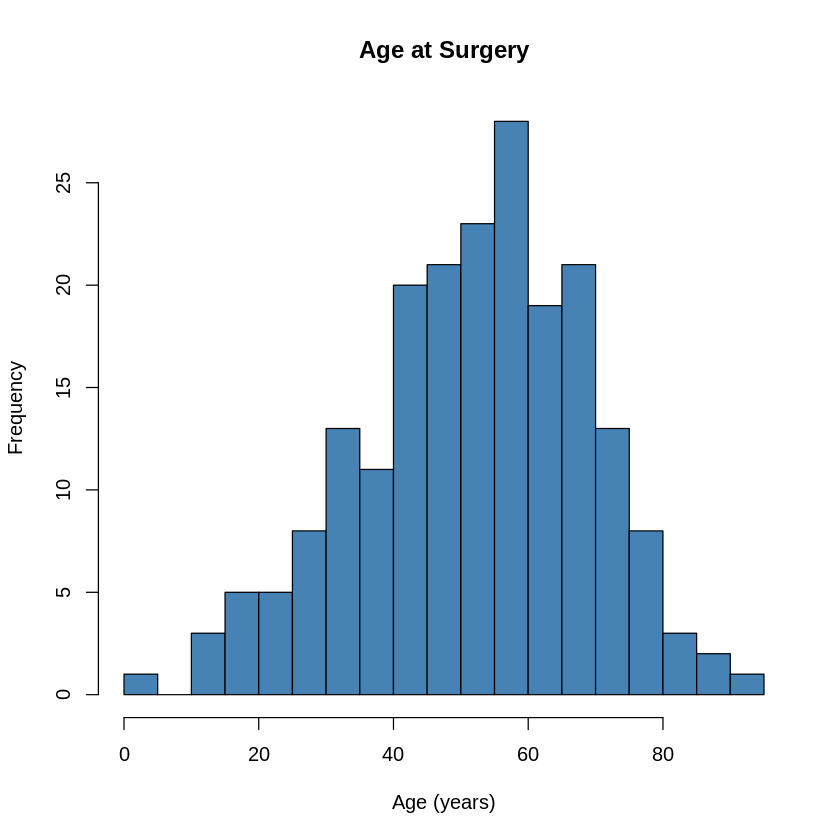

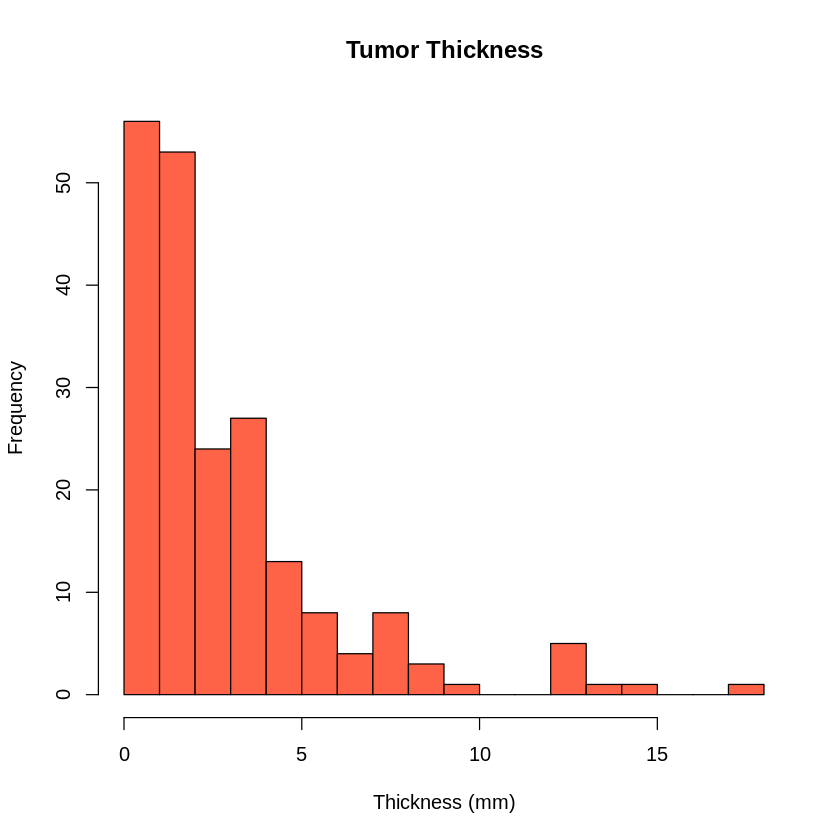

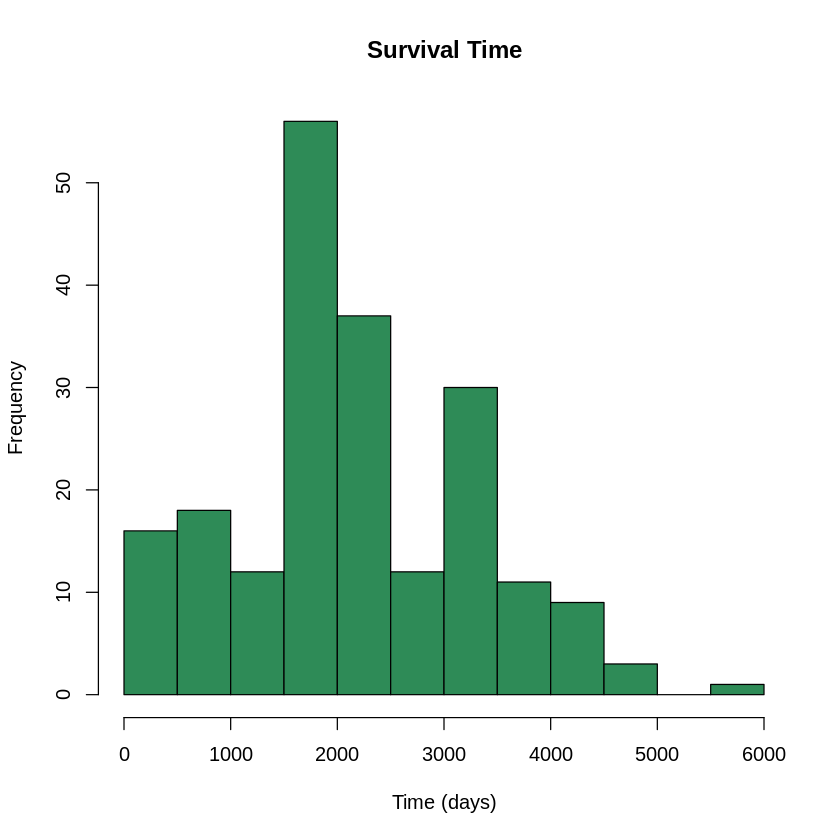

In [14]:
hist(melanoma$age,
     main = "Age at Surgery",
     xlab = "Age (years)",
     col = "steelblue",
     breaks = 15)

hist(melanoma$thickness,
     main = "Tumor Thickness",
     xlab = "Thickness (mm)",
     col = "tomato",
     breaks = 15)

hist(melanoma$time,
     main = "Survival Time",
     xlab = "Time (days)",
     col = "seagreen",
     breaks = 15)

Tumor thickness is notably right-skewed, suggesting that a small number of patients have very thick tumors. This is worth acknowledging, though for logistic regression this does not violate model assumptions directly.

### 2.3 Categorical Predictors: Sex and Ulceration


In [15]:
# Count sex distribution
cat("Sex distribution (0 = female, 1 = male):
")
print(table(melanoma$sex))

# Count ulceration distribution
cat("
Ulceration distribution (0 = absent, 1 = present):
")
print(table(melanoma$ulcer))


Sex distribution (0 = female, 1 = male):

  0   1 
126  79 

Ulceration distribution (0 = absent, 1 = present):

  0   1 
115  90 


In [16]:
# Cross-tabulate ulceration and melanoma death
cat("Melanoma death by ulceration status:
")
print(table(Ulcer = melanoma$ulcer, Died_Melanoma = melanoma$died_melanoma))

# Cross-tabulate sex and melanoma death
cat("
Melanoma death by sex:
")
print(table(Sex = melanoma$sex, Died_Melanoma = melanoma$died_melanoma))


Melanoma death by ulceration status:
     Died_Melanoma
Ulcer  0  1
    0 99 16
    1 49 41

Melanoma death by sex:
   Died_Melanoma
Sex  0  1
  0 98 28
  1 50 29


These cross-tabulations offer a look at the relationship between our categorical predictors and the outcome. The presence of ulceration appears to be associated with a higher rate of melanoma-related death. Sex differences are present but less striking.


In [17]:
# Compute means of continuous variables split by outcome
cat("Mean age by melanoma death status:
")
print(tapply(melanoma$age, melanoma$died_melanoma, mean))

cat("
Mean tumor thickness by melanoma death status:
")
print(tapply(melanoma$thickness, melanoma$died_melanoma, mean))

cat("
Mean survival time by melanoma death status:
")
print(tapply(melanoma$time, melanoma$died_melanoma, mean))


Mean age by melanoma death status:
       0        1 
51.45270 55.08772 

Mean tumor thickness by melanoma death status:
       0        1 
2.384054 4.311053 

Mean survival time by melanoma death status:
       0        1 
2499.365 1252.947 


The group means hint at the idea that patients who died from melanoma tended to have thicker tumors on average. Survival time is notably shorter in the died-from-melanoma group, which makes intuitive sense given that shorter follow-up time implies earlier death.

Although `time` (survival time from surgery) is in the dataset, we will exclude it from our logistic regression model. Survival time is a post-outcome measure that is determined jointly by when the patient died and when the study ended. Including it in a model predicting death would introduce issues with temporal causality (the outcome influences the predictor, not the other way around). All other variables were measured at or before the time of surgery and are thus appropriate predictors.


---
## Section 3: Correlation Analysis and Multicollinearity

Before fitting a logistic regression model with multiple predictors, we should examine the pairwise correlations among our predictors. High correlations (roughly r > 0.8) between predictors can inflate standard errors and make it difficult to interpret which predictor is doing the work. Moderate correlations (around r ≈ 0.3) are generally not a concern and do not require remediation.

We will compute a correlation matrix on numeric variables (categorical variables cannot be included directly).


In [20]:
# Select the numeric predictors for the correlation matrix
# Exclude: status (original outcome), died_melanoma (derived outcome), time (excluded for reasons above)
pred_vars <- melanoma[, c("age", "sex", "year", "thickness", "ulcer")]

# Compute pairwise correlations
cxy <- cor(pred_vars)
print(round(cxy, 3))


            age    sex   year thickness  ulcer
age       1.000  0.068  0.188     0.212  0.126
sex       0.068  1.000 -0.003     0.185  0.168
year      0.188 -0.003  1.000    -0.133 -0.033
thickness 0.212  0.185 -0.133     1.000  0.424
ulcer     0.126  0.168 -0.033     0.424  1.000


Now we'll visualize this correlation matrix.


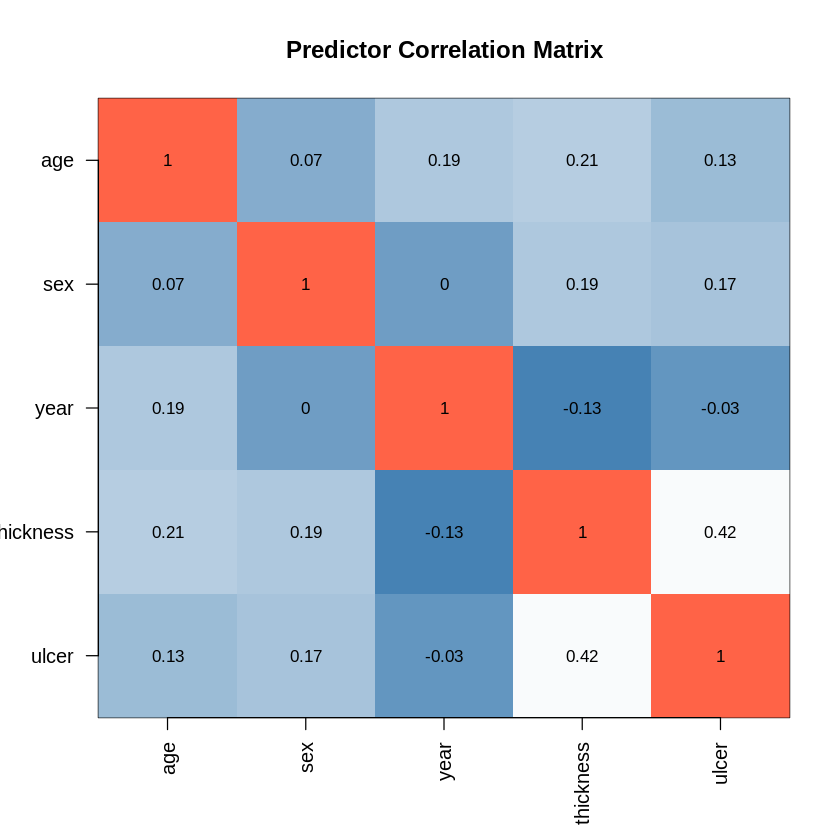

In [22]:
# Visualize the correlation matrix as a heatmap
cor_matrix <- round(cor(pred_vars), 2)

image(1:ncol(cor_matrix), 1:nrow(cor_matrix),
      t(cor_matrix[nrow(cor_matrix):1, ]),
      col  = colorRampPalette(c("steelblue", "white", "tomato"))(100),
      xaxt = "n", yaxt = "n",
      xlab = "", ylab = "",
      main = "Predictor Correlation Matrix")

axis(1, at = 1:ncol(cor_matrix), labels = colnames(cor_matrix), las = 2)
axis(2, at = 1:nrow(cor_matrix), labels = rev(rownames(cor_matrix)), las = 1)

# Add correlation value labels
for (i in 1:nrow(cor_matrix)) {
  for (j in 1:ncol(cor_matrix)) {
    text(j, nrow(cor_matrix) + 1 - i,
         labels = cor_matrix[i, j],
         cex = 0.85)
  }
}


### Interpretation

Examining the correlation matrix, we can draw the following conclusions:

- **`thickness` and `ulcer`** show the most notable positive correlation among our predictors, which makes clinical sense: thicker tumors are more likely to be ulcerated. However, this correlation is moderate rather than extreme, so it does not require us to drop a variable.
- All other pairwise correlations among predictors are weak (generally below 0.3 in absolute value).
- There is no evidence of severe multicollinearity (r > 0.8 or 0.9) in this predictor set. We can proceed with including all five predictors in the logistic regression.

---
## Section 4: Binary Logistic Regression

We can now fit our primary model.

Our full model predicts melanoma-related death from all five available pre-surgical predictors:

$$\text{logit}(P(\text{died\_melanoma} = 1)) = \beta_0 + \beta_1 \cdot \text{age} + \beta_2 \cdot \text{sex} + \beta_3 \cdot \text{year} + \beta_4 \cdot \text{thickness} + \beta_5 \cdot \text{ulcer}$$


In [23]:
# Fit the full binary logistic regression model
glm.fit <- glm(died_melanoma ~ age + sex + year + thickness + ulcer,
               data   = melanoma,
               family = binomial)

# Summarize
summary(glm.fit)



Call:
glm(formula = died_melanoma ~ age + sex + year + thickness + 
    ulcer, family = binomial, data = melanoma)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) 400.72733  143.11055   2.800 0.005108 ** 
age           0.01195    0.01109   1.078 0.281175    
sex           0.46677    0.35431   1.317 0.187704    
year         -0.20489    0.07276  -2.816 0.004866 ** 
thickness     0.08660    0.06091   1.422 0.155074    
ulcer         1.41849    0.38162   3.717 0.000202 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 242.35  on 204  degrees of freedom
Residual deviance: 202.01  on 199  degrees of freedom
AIC: 214.01

Number of Fisher Scoring iterations: 4


### 4.1 Interpreting the Coefficients

The model output reports log-odds coefficients. A positive coefficient means that as the predictor increases, the log-odds of dying from melanoma increase (and thus the probability increases). A negative coefficient means the opposite.

In [24]:
# Extract and display the coefficients table cleanly
coef_table <- summary(glm.fit)$coefficients
print(round(coef_table, 4))


            Estimate Std. Error z value Pr(>|z|)
(Intercept) 400.7273   143.1106  2.8001   0.0051
age           0.0119     0.0111  1.0777   0.2812
sex           0.4668     0.3543  1.3174   0.1877
year         -0.2049     0.0728 -2.8158   0.0049
thickness     0.0866     0.0609  1.4218   0.1551
ulcer         1.4185     0.3816  3.7170   0.0002


In [25]:
# Report AIC for model fit reference
cat("AIC:", AIC(glm.fit), "
")
cat("Null deviance:", glm.fit$null.deviance, "on", glm.fit$df.null, "df
")
cat("Residual deviance:", glm.fit$deviance, "on", glm.fit$df.residual, "df
")


AIC: 214.0147 
Null deviance: 242.3514 on 204 df
Residual deviance: 202.0147 on 199 df


### 4.2 Predicted Probabilities on Training Data

We can now examine the predicted probabilities the model assigns to each observation in the training data. These are continuous estimates of P(died from melanoma).


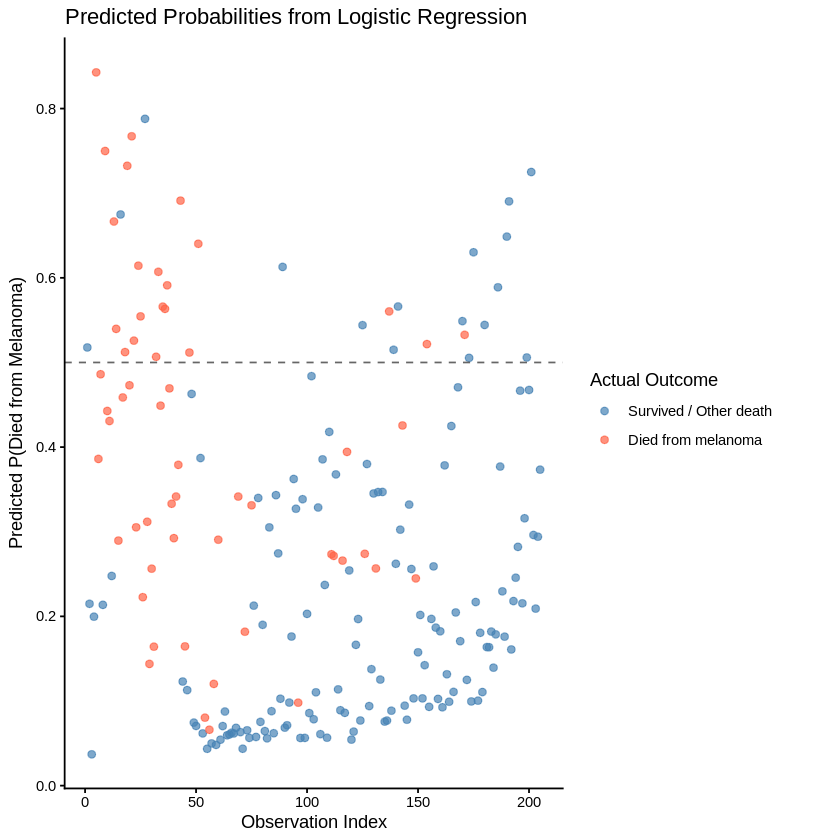

In [26]:
# Get predicted probabilities for the training data
glm_prob_df <- data.frame(
  predicted_prob = predict(glm.fit, type = "response")
)
num_obs <- nrow(glm_prob_df)
glm_prob_df$index <- seq(1, num_obs)
glm_prob_df$actual <- melanoma$died_melanoma

# Plot predicted probabilities, colored by true outcome
ggplot(glm_prob_df, aes(x = index, y = predicted_prob, color = factor(actual))) +
  geom_point(alpha = 0.7, size = 1.8) +
  scale_color_manual(values = c("0" = "steelblue", "1" = "tomato"),
                     labels = c("0" = "Survived / Other death", "1" = "Died from melanoma")) +
  labs(title  = "Predicted Probabilities from Logistic Regression",
       x      = "Observation Index",
       y      = "Predicted P(Died from Melanoma)",
       color  = "Actual Outcome") +
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "gray40") +
  theme_classic()


The dashed line at 0.5 represents the default classification threshold. Observations above the line would be predicted as melanoma deaths and those below as survivors.

### 4.3 Confusion Matrix and Training Accuracy


In [27]:
# Binarize predictions at threshold = 0.5
threshold <- 0.50
glm_prob_df$predicted_binary <- ifelse(glm_prob_df$predicted_prob > threshold, 1, 0)

# Build confusion matrix
confusion_df <- data.frame(
  predicted = glm_prob_df$predicted_binary,
  actual    = glm_prob_df$actual
)

cat("Confusion Matrix (Training Data):
")
print(table(Predicted = confusion_df$predicted, Actual = confusion_df$actual))

# Overall training accuracy
train_acc <- mean(confusion_df$predicted == confusion_df$actual)
cat("
Training Accuracy:", round(train_acc, 4), "
")


Confusion Matrix (Training Data):
         Actual
Predicted   0   1
        0 132  36
        1  16  21

Training Accuracy: 0.7463 


---
## Section 5: K-Fold Cross-Validation

Training accuracy is biased because the model sees the test data during training, so cross-validation addresses this by repeatedly partitioning the data into training and test folds.

We will use a **10-fold cross-validation** here.


In [28]:
library(boot)

# Set seed for reproducibility
set.seed(42)

# Define a custom cost function: misclassification rate at threshold 0.5
# cost(observed, predicted_probability) -> error rate
cost_fn <- function(actual, predicted_prob) {
  predicted_binary <- ifelse(predicted_prob > 0.5, 1, 0)
  mean(predicted_binary != actual)  # misclassification rate
}

# Run 10-fold cross-validation
cv.err <- cv.glm(melanoma, glm.fit, cost = cost_fn, K = 10)

cat("10-fold CV Misclassification Error:", round(cv.err$delta[1], 4), "
")
cat("10-fold CV Accuracy:", round(1 - cv.err$delta[1], 4), "
")


10-fold CV Misclassification Error: 0.2683 
10-fold CV Accuracy: 0.7317 


The cross-validated accuracy gives us a more honest estimate of how well this model would generalize to new patients.

In [30]:
# For transparency, we'll also run it without a custom cost function
# (this gives MSE on predicted probabilities,)
cv.err.mse <- cv.glm(melanoma, glm.fit, K = 10)
cat("10-fold CV MSE (probability scale):", round(cv.err.mse$delta[1], 4), "
")


10-fold CV MSE (probability scale): 0.1751 


---
## Section 6: Bootstrapping the Logistic Regression Coefficients

Cross-validation tells us about prediction accuracy, but it does not directly address uncertainty in our coefficient estimates. For that, we will use **bootstrapping** with R = 1000 iterations.


In [33]:
# Define the bootstrapping function
boot.logit <- function(data, index) {
  fit <- glm(died_melanoma ~ age + sex + year + thickness + ulcer,
             data   = data[index, ],
             family = binomial)
  return(coef(fit))
}

# Test the function on all observations
print(boot.logit(melanoma, 1:nrow(melanoma)))


 (Intercept)          age          sex         year    thickness        ulcer 
400.72732672   0.01194915   0.46677039  -0.20488600   0.08659699   1.41848525 


In [34]:
# Run the bootstrap with 1000 iterations
set.seed(42)
boot_obj <- boot(melanoma, boot.logit, R = 1000)
print(boot_obj)



ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = melanoma, statistic = boot.logit, R = 1000)


Bootstrap Statistics :
        original        bias     std. error
t1* 400.72732672 24.3038451441 159.15785630
t2*   0.01194915  0.0002028079   0.01404670
t3*   0.46677039  0.0023024080   0.38327677
t4*  -0.20488600 -0.0123867926   0.08092691
t5*   0.08659699  0.0030040578   0.06207013
t6*   1.41848525  0.0680025976   0.40459302


Now we will visualize the bootstrap distributions for the two predictors that are most likely to be clinically meaningful: `thickness` and `ulcer`.


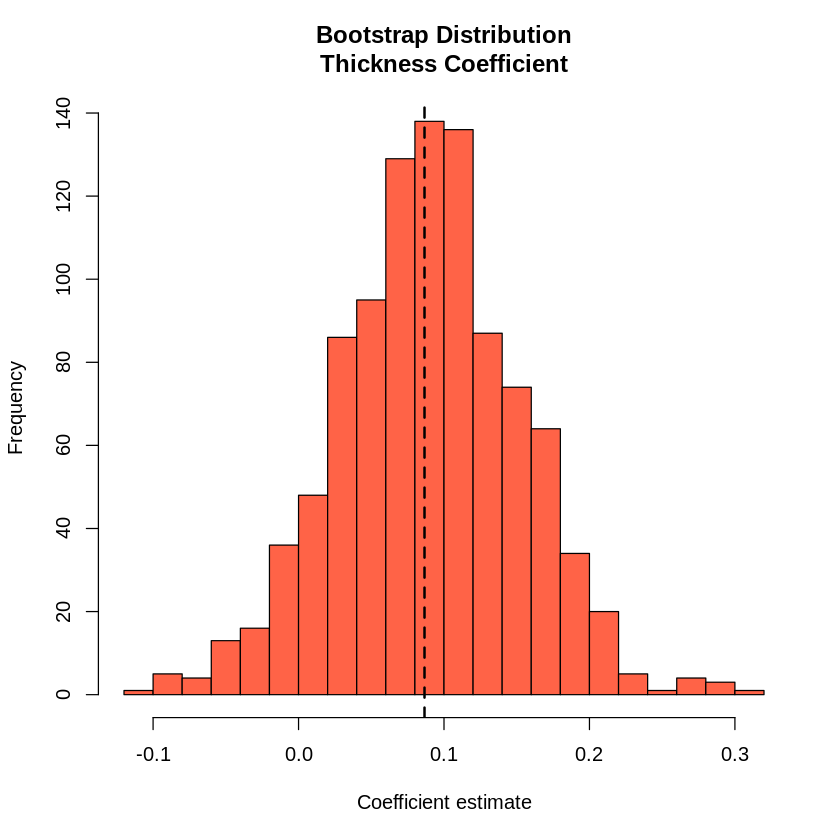

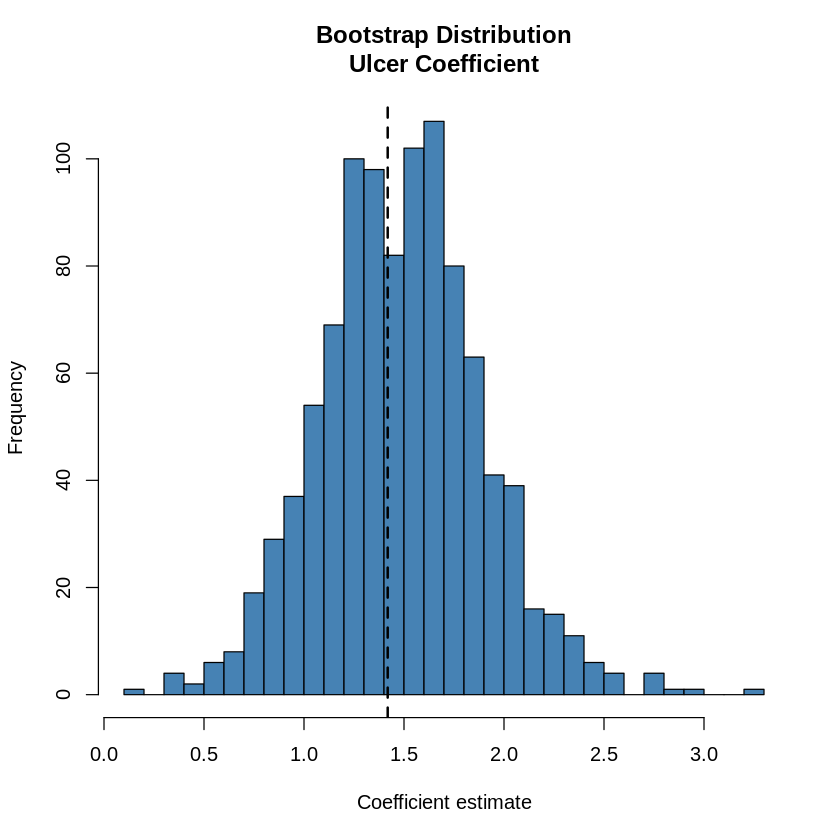

In [36]:
# Plot bootstrap distributions for thickness and ulcer coefficients
# thickness is column 5 (intercept=1, age=2, sex=3, year=4, thickness=5, ulcer=6)

hist(boot_obj$t[, 5],
     main = "Bootstrap Distribution
Thickness Coefficient",
     xlab = "Coefficient estimate",
     col  = "tomato",
     breaks = 30)
abline(v = coef(glm.fit)["thickness"], col = "black", lwd = 2, lty = 2)

hist(boot_obj$t[, 6],
     main = "Bootstrap Distribution
Ulcer Coefficient",
     xlab = "Coefficient estimate",
     col  = "steelblue",
     breaks = 30)
abline(v = coef(glm.fit)["ulcer"], col = "black", lwd = 2, lty = 2)


The dashed vertical line in each histogram marks the original coefficient estimate from the full model. A narrow, symmetric distribution centered on the original estimate indicates a stable, well-estimated coefficient.


In [37]:
# Extract 95% bootstrap confidence intervals for all coefficients
cat("95% Bootstrap Confidence Intervals (percentile method):

")
for (i in 1:6) {
  ci <- quantile(boot_obj$t[, i], probs = c(0.025, 0.975))
  coef_name <- names(coef(glm.fit))[i]
  cat(sprintf("%-15s  [%7.4f, %7.4f]
", coef_name, ci[1], ci[2]))
}


95% Bootstrap Confidence Intervals (percentile method):

(Intercept)      [132.4804, 738.4380]
age              [-0.0150,  0.0396]
sex              [-0.2967,  1.2012]
year             [-0.3764, -0.0689]
thickness        [-0.0386,  0.2064]
ulcer            [ 0.7164,  2.3252]


These confidence intervals provide a non-parametric sense of the uncertainty around each coefficient. A confidence interval that does not include zero provides evidence that the predictor has a reliable association with the outcome.


---
## Section 7: Discussion and Conclusions

### Summary of Findings

This project set out to answer the question: *What patient and tumor characteristics predict melanoma-related death, and how well can a binary logistic regression model classify survival outcomes?*

**Descriptive findings** established that approximately one-third of the 205 patients in this cohort died from melanoma. Tumor thickness was notably right-skewed, and both thickness and ulceration showed the most visible associations with the outcome in exploratory cross-tabulations.

**Correlation analysis** confirmed that `thickness` and `ulcer` are the most intercorrelated predictors in this dataset, which is clinically interpretable since thicker tumors are more prone to ulceration. However, the correlation was moderate, and no predictor pair approached the threshold (r > 0.8–0.9) that would warrant dropping a variable for multicollinearity. All five predictors were retained in the model.

**Binary logistic regression** modeled melanoma death as a function of age, sex, year, tumor thickness, and ulceration. The model showed a reduction in deviance from the null model, indicating that the predictors collectively provide useful information. Among the predictors, tumor thickness and ulceration are the most clinically and statistically interesting, consistent with the established literature on melanoma. The direction of all coefficients aligns with clinical expectations: thicker, ulcerated tumors predict worse outcomes.

**Cross-validation** provided an estimate of out-of-sample performance. The 10-fold CV accuracy is a more principled figure than training accuracy alone, because it evaluates the model on data it has never seen. Any gap between training and CV accuracy reflects overfitting.

**Bootstrapping** offered a non-parametric characterization of uncertainty in the coefficient estimates. Bootstrap confidence intervals for thickness and ulceration that exclude zero would support the parametric p-values and give additional confidence that these associations are not just noise.

### Limitations

Several limitations deserve acknowledgment. First, this is an observational cohort study, so causal inference cannot be established. Second, the relatively small sample size (n = 205) limits the precision of all estimates and increases the risk of overfitting. Third, the dataset was collected between 1962 and 1977, and many medical advances and technology have improved since then, limiting generalizability. Fourth, binarizing `status` required a judgment call about patients who died from other causes, so a different analytic choice could've yielded different results.

### Conclusion

This analysis demonstrates that tumor characteristics, particularly thickness and ulceration, are meaningfully associated with melanoma-related mortality. A logistic regression model using five pre-surgical variables achieves classification performance above chance, with cross-validated accuracy providing a reliable estimate of generalizability. Bootstrapping corroborates the parametric uncertainty estimates for key predictors.
